In [1]:
# ── §1 · Setup ────────────────────────────────────────────────────────────────
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..')
import nflreadpy as nfl
from src.simulation import run_monte_carlo, TEAM_CONF, TEAM_DIV

# Parámetros calibrados en Notebook 02
HOME_ADVANTAGE    = 42.2
K_REGULAR         = 40
K_PLAYOFFS        = 48
REGRESSION_FACTOR = 0.40
GLOBAL_MEAN       = 1503.1
N_SIMS            = 10_000 # 100_000

In [2]:
# ── §2 · Cargar datos ─────────────────────────────────────────────────────────
# Schedule 2026
schedule_2026 = nfl.load_schedules(seasons = [2026]).to_pandas()
print(f"Partidos REG 2026: {(schedule_2026['game_type']=='REG').sum()}")

# ELOs finales 2025
final_elos_df = pd.read_csv('../data/processed/elo_final_2025.csv')
final_elos    = dict(zip(final_elos_df['team'], final_elos_df['elo_final']))

print(f"Equipos con ELO  : {len(final_elos)}")
print(f"\nTop 5 ELO 2025:")
print(final_elos_df.head(5).to_string(index=False))

Partidos REG 2026: 272
Equipos con ELO  : 32

Top 5 ELO 2025:
team  elo_final
 SEA  1736.8451
 DEN  1655.8258
  NE  1652.6299
 HOU  1634.0275
 BUF  1629.5989


In [3]:

# ── §3 · Ejecutar Monte Carlo ─────────────────────────────────────────────────
results_df, wins_dist, game_results_df = run_monte_carlo(
    schedule_df=schedule_2026,
    final_elos_2025=final_elos,
    home_advantage=HOME_ADVANTAGE,
    k_regular=K_REGULAR,
    k_playoffs=K_PLAYOFFS,
    regression_factor=REGRESSION_FACTOR,
    global_mean=GLOBAL_MEAN,
    n_sims=N_SIMS,
    seed=42,
)
# ── §4 · Resultados ───────────────────────────────────────────────────────────
print("\n=== Predicciones Temporada 2026 ===\n")
print(results_df.to_string(index=False))

Monte Carlo 2026: 100%|██████████| 10000/10000 [00:26<00:00, 372.80it/s]


=== Predicciones Temporada 2026 ===

team conf  division  avg_wins  std_wins  pct_playoffs  pct_div_winner  pct_conf_champ  pct_sb_winner
 SEA  NFC  NFC_West     11.56      2.59          80.9            50.1            22.3           12.8
 DEN  AFC  AFC_West     10.45      2.82          71.2            52.1            14.5            7.8
 HOU  AFC AFC_South     10.50      2.80          70.6            47.3            13.1            6.8
  NE  AFC  AFC_East     10.16      2.78          67.7            43.5            13.6            7.4
 BUF  AFC  AFC_East      9.85      2.80          63.8            37.8            11.7            6.0
 PHI  NFC  NFC_East      9.94      2.84          63.4            49.2            10.2            5.2
  LA  NFC  NFC_West      9.98      2.79          60.7            25.6            10.7            5.9
 DET  NFC NFC_North      9.71      2.81          57.2            30.9             7.9            3.8
 JAX  AFC AFC_South      9.45      2.84          56.9

In [4]:
# ── §5 · Guardar outputs ──────────────────────────────────────────────────────
from pathlib import Path
Path('../data/processed').mkdir(parents=True, exist_ok=True)

results_df.to_csv('../data/processed/predictions_2026.csv', index=False)
wins_dist.to_csv('../data/processed/wins_distribution_2026.csv', index=False)
game_results_df.to_csv('../data/processed/game_results_2026.csv', index=False)

print("\nOutputs guardados.")


Outputs guardados.


---

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Paleta de colores ─────────────────────────────────────────────────────────
AFC_COLOR  = '#003f88'
NFC_COLOR  = '#c8102e'
GRAY_LIGHT = '#e8e8e8'
GRAY_MID   = '#aaaaaa'

# ── Ordenar por conferencia y avg_wins ────────────────────────────────────────
afc = results_df[results_df['conf'] == 'AFC'].sort_values('avg_wins', ascending=True)
nfc = results_df[results_df['conf'] == 'NFC'].sort_values('avg_wins', ascending=True)

from pathlib import Path
Path('../results').mkdir(parents=True, exist_ok=True)

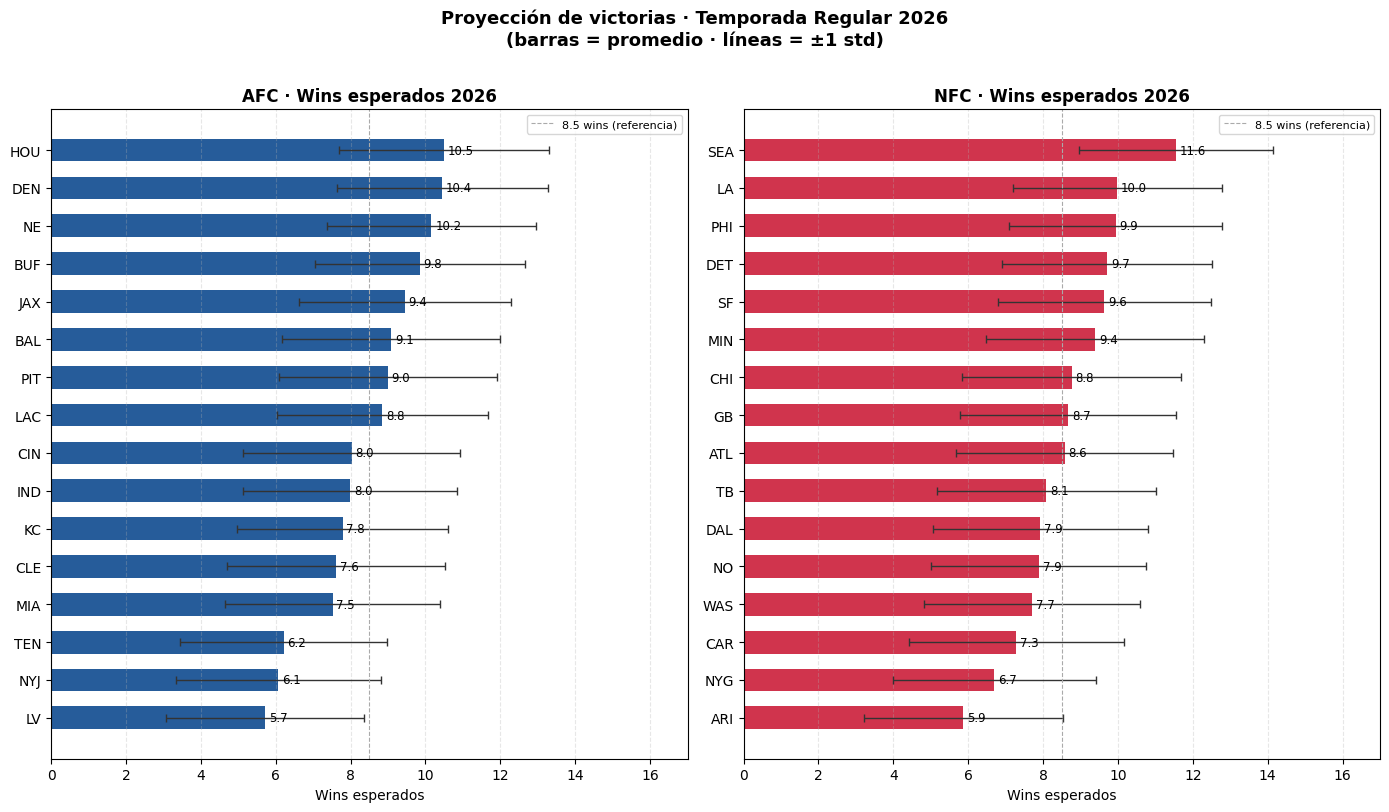

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, conf_df, color, conf_name in [
    (axes[0], afc, AFC_COLOR, 'AFC'),
    (axes[1], nfc, NFC_COLOR, 'NFC'),
]:
    bars = ax.barh(conf_df['team'], conf_df['avg_wins'],
                   color=color, alpha=0.85, height=0.6)
    ax.errorbar(conf_df['avg_wins'], conf_df['team'],
                xerr=conf_df['std_wins'],
                fmt='none', color='#333333', capsize=3, linewidth=1)

    # Etiquetas
    for bar, val in zip(bars, conf_df['avg_wins']):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=8.5)

    ax.axvline(8.5, color=GRAY_MID, linestyle='--',
               linewidth=0.8, label='8.5 wins (referencia)')
    ax.set_xlim(0, 17)
    ax.set_xlabel('Wins esperados')
    ax.set_title(f'{conf_name} · Wins esperados 2026', fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Proyección de victorias · Temporada Regular 2026\n(barras = promedio · líneas = ±1 std)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/viz1_avg_wins.png', dpi=150, bbox_inches='tight')
plt.show()

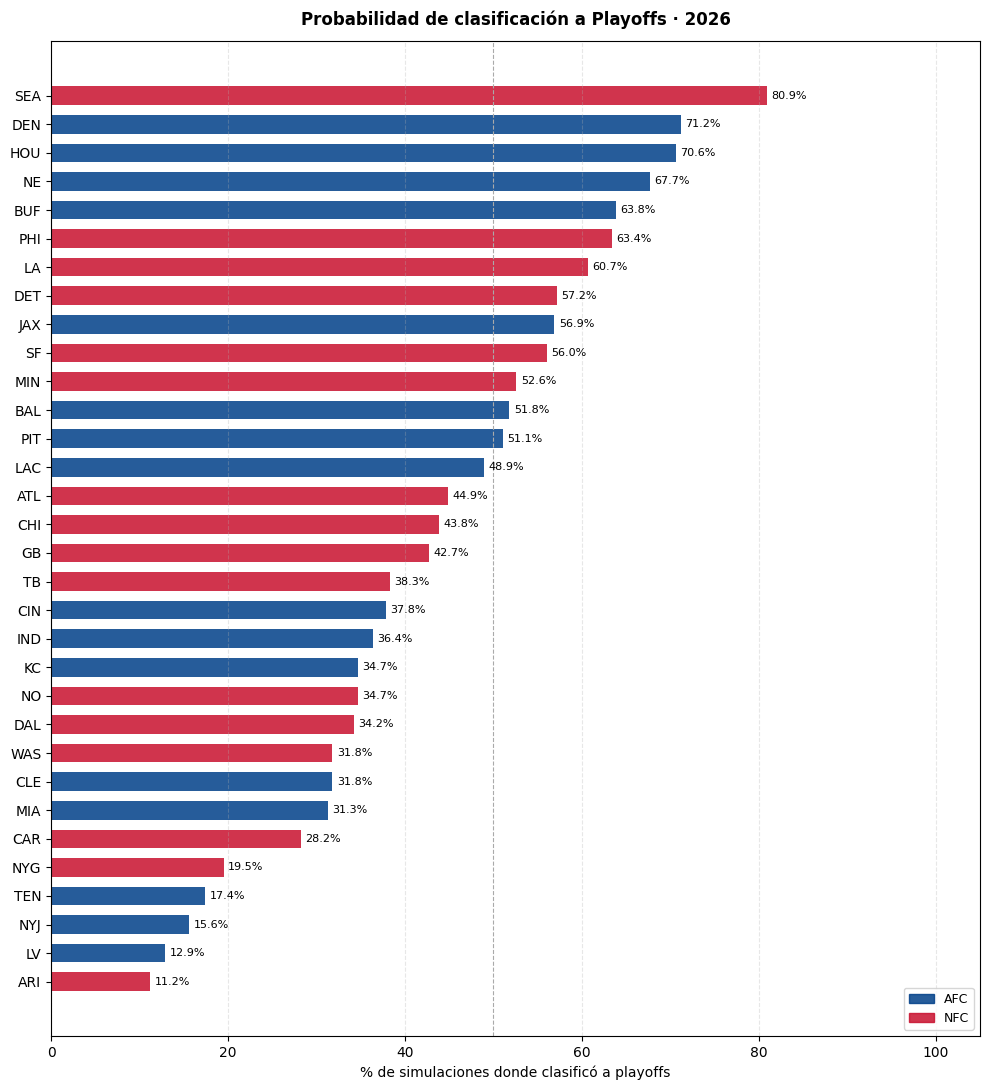

In [7]:
all_sorted = results_df.sort_values('pct_playoffs', ascending=True)
colors     = [AFC_COLOR if c == 'AFC' else NFC_COLOR for c in all_sorted['conf']]

fig, ax = plt.subplots(figsize=(10, 11))

bars = ax.barh(all_sorted['team'], all_sorted['pct_playoffs'],
               color=colors, alpha=0.85, height=0.65)

# Línea de 50%
ax.axvline(50, color=GRAY_MID, linestyle='--', linewidth=0.8)

# Etiquetas
for bar, val in zip(bars, all_sorted['pct_playoffs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

# Leyenda
afc_patch = mpatches.Patch(color=AFC_COLOR, alpha=0.85, label='AFC')
nfc_patch = mpatches.Patch(color=NFC_COLOR, alpha=0.85, label='NFC')
ax.legend(handles=[afc_patch, nfc_patch], loc='lower right', fontsize=9)

ax.set_xlim(0, 105)
ax.set_xlabel('% de simulaciones donde clasificó a playoffs')
ax.set_title('Probabilidad de clasificación a Playoffs · 2026',
             fontweight='bold', pad=12)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/viz2_pct_playoffs.png', dpi=150, bbox_inches='tight')
plt.show()

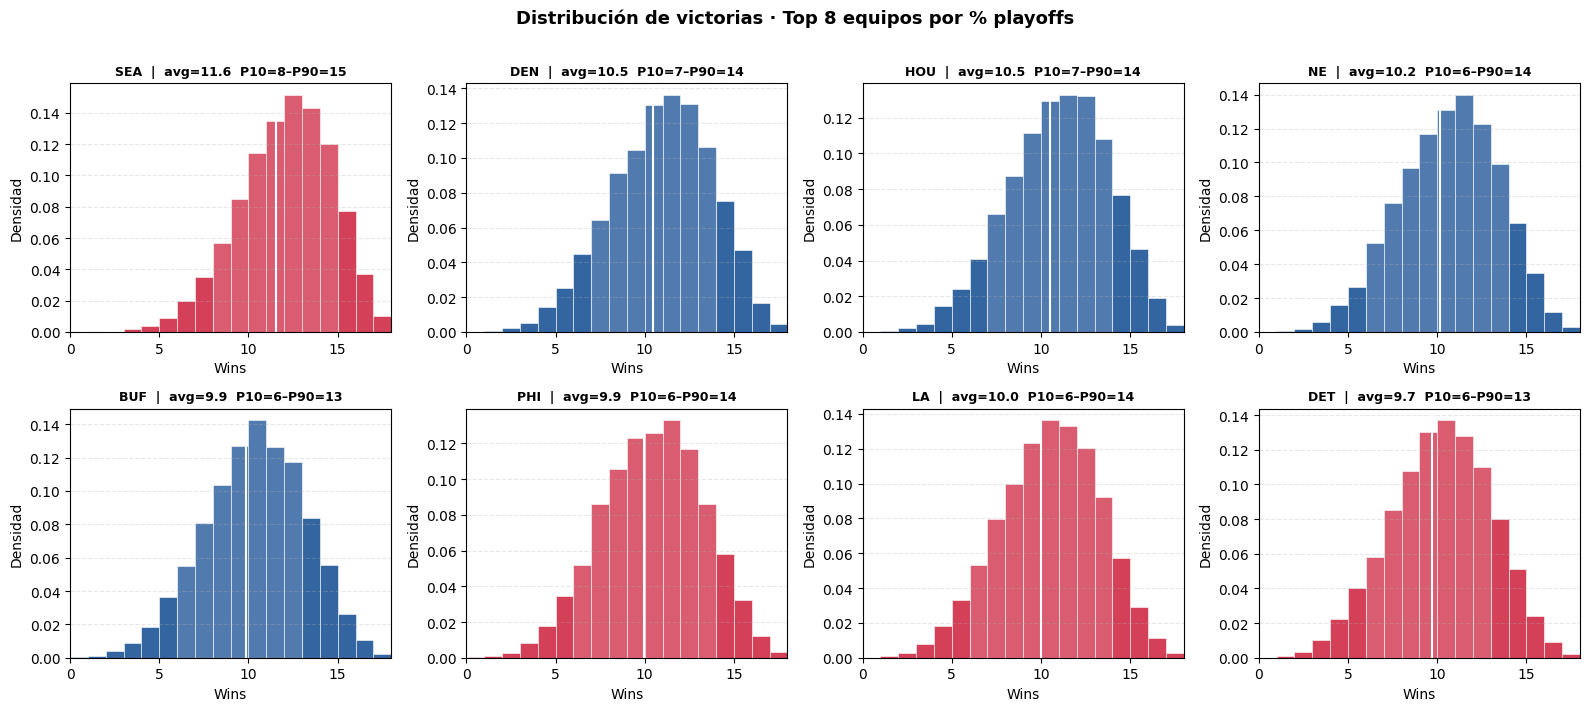

In [8]:
top8 = results_df.nlargest(8, 'pct_playoffs')['team'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, team in enumerate(top8):
    ax    = axes[i]
    color = AFC_COLOR if TEAM_CONF[team] == 'AFC' else NFC_COLOR
    wins  = wins_dist[team]

    ax.hist(wins, bins=range(0, 19), color=color, alpha=0.8,
            edgecolor='white', linewidth=0.5, density=True)

    # Media y percentiles
    mean = wins.mean()
    p10  = np.percentile(wins, 10)
    p90  = np.percentile(wins, 90)

    ax.axvline(mean, color='white', linewidth=1.5, linestyle='-')
    ax.axvspan(p10, p90, alpha=0.15, color='white')

    ax.set_title(f'{team}  |  avg={mean:.1f}  P10={p10:.0f}–P90={p90:.0f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Wins')
    ax.set_ylabel('Densidad')
    ax.set_xlim(0, 18)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Distribución de victorias · Top 8 equipos por % playoffs',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/viz3_wins_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

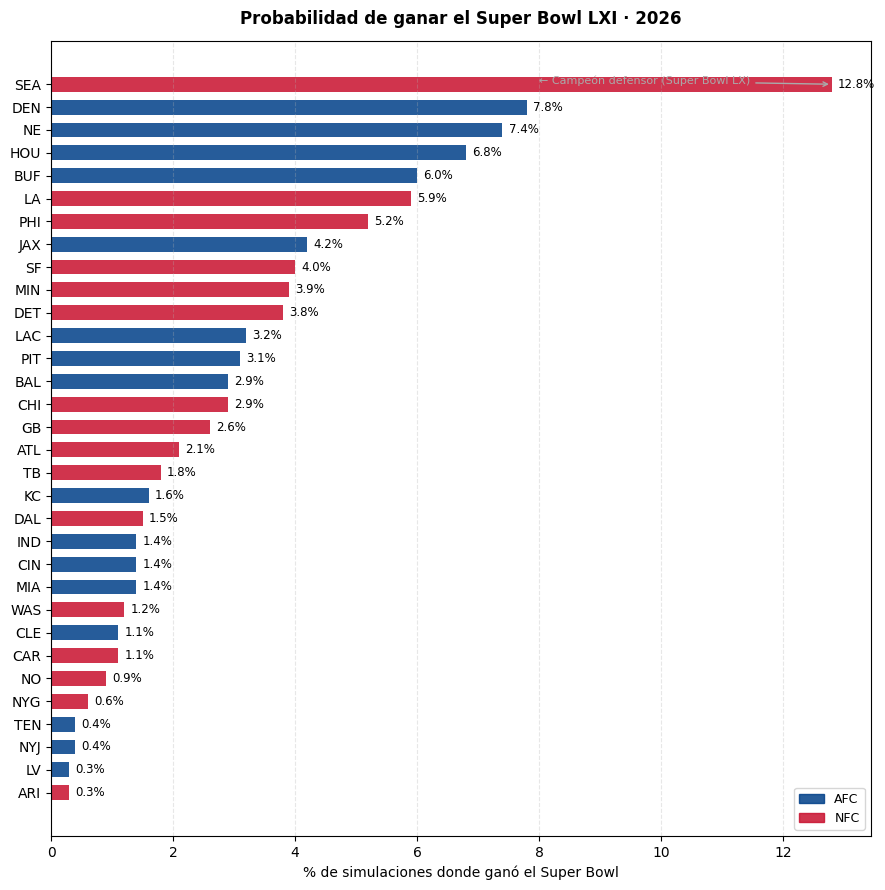

In [9]:
sb = results_df[results_df['pct_sb_winner'] > 0].sort_values(
    'pct_sb_winner', ascending=True
)
colors_sb = [AFC_COLOR if c == 'AFC' else NFC_COLOR for c in sb['conf']]

fig, ax = plt.subplots(figsize=(9, 9))

bars = ax.barh(sb['team'], sb['pct_sb_winner'],
               color=colors_sb, alpha=0.85, height=0.65)

for bar, val in zip(bars, sb['pct_sb_winner']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8.5)

afc_patch = mpatches.Patch(color=AFC_COLOR, alpha=0.85, label='AFC')
nfc_patch = mpatches.Patch(color=NFC_COLOR, alpha=0.85, label='NFC')
ax.legend(handles=[afc_patch, nfc_patch], loc='lower right', fontsize=9)

ax.set_xlabel('% de simulaciones donde ganó el Super Bowl')
ax.set_title('Probabilidad de ganar el Super Bowl LXI · 2026',
             fontweight='bold', pad=12)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Nota del campeón defensor
ax.annotate('← Campeón defensor (Super Bowl LX)',
            xy=(sb[sb['team']=='SEA']['pct_sb_winner'].values[0], 'SEA'),
            xytext=(8, 'SEA'),
            fontsize=8, color=GRAY_MID,
            arrowprops=dict(arrowstyle='->', color=GRAY_MID))

plt.tight_layout()
plt.savefig('../results/viz4_pct_sb_winner.png', dpi=150, bbox_inches='tight')
plt.show()

/Users/sebastianbp/Documents/GitHub/nfl_probability_engine/Notebooks/../src/visualization.py:613: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from current font.
  plt.tight_layout(pad=0)
/Users/sebastianbp/Documents/GitHub/nfl_probability_engine/Notebooks/../src/visualization.py:616: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight',


Guardado: ../results/schedule_SEA_2026.png


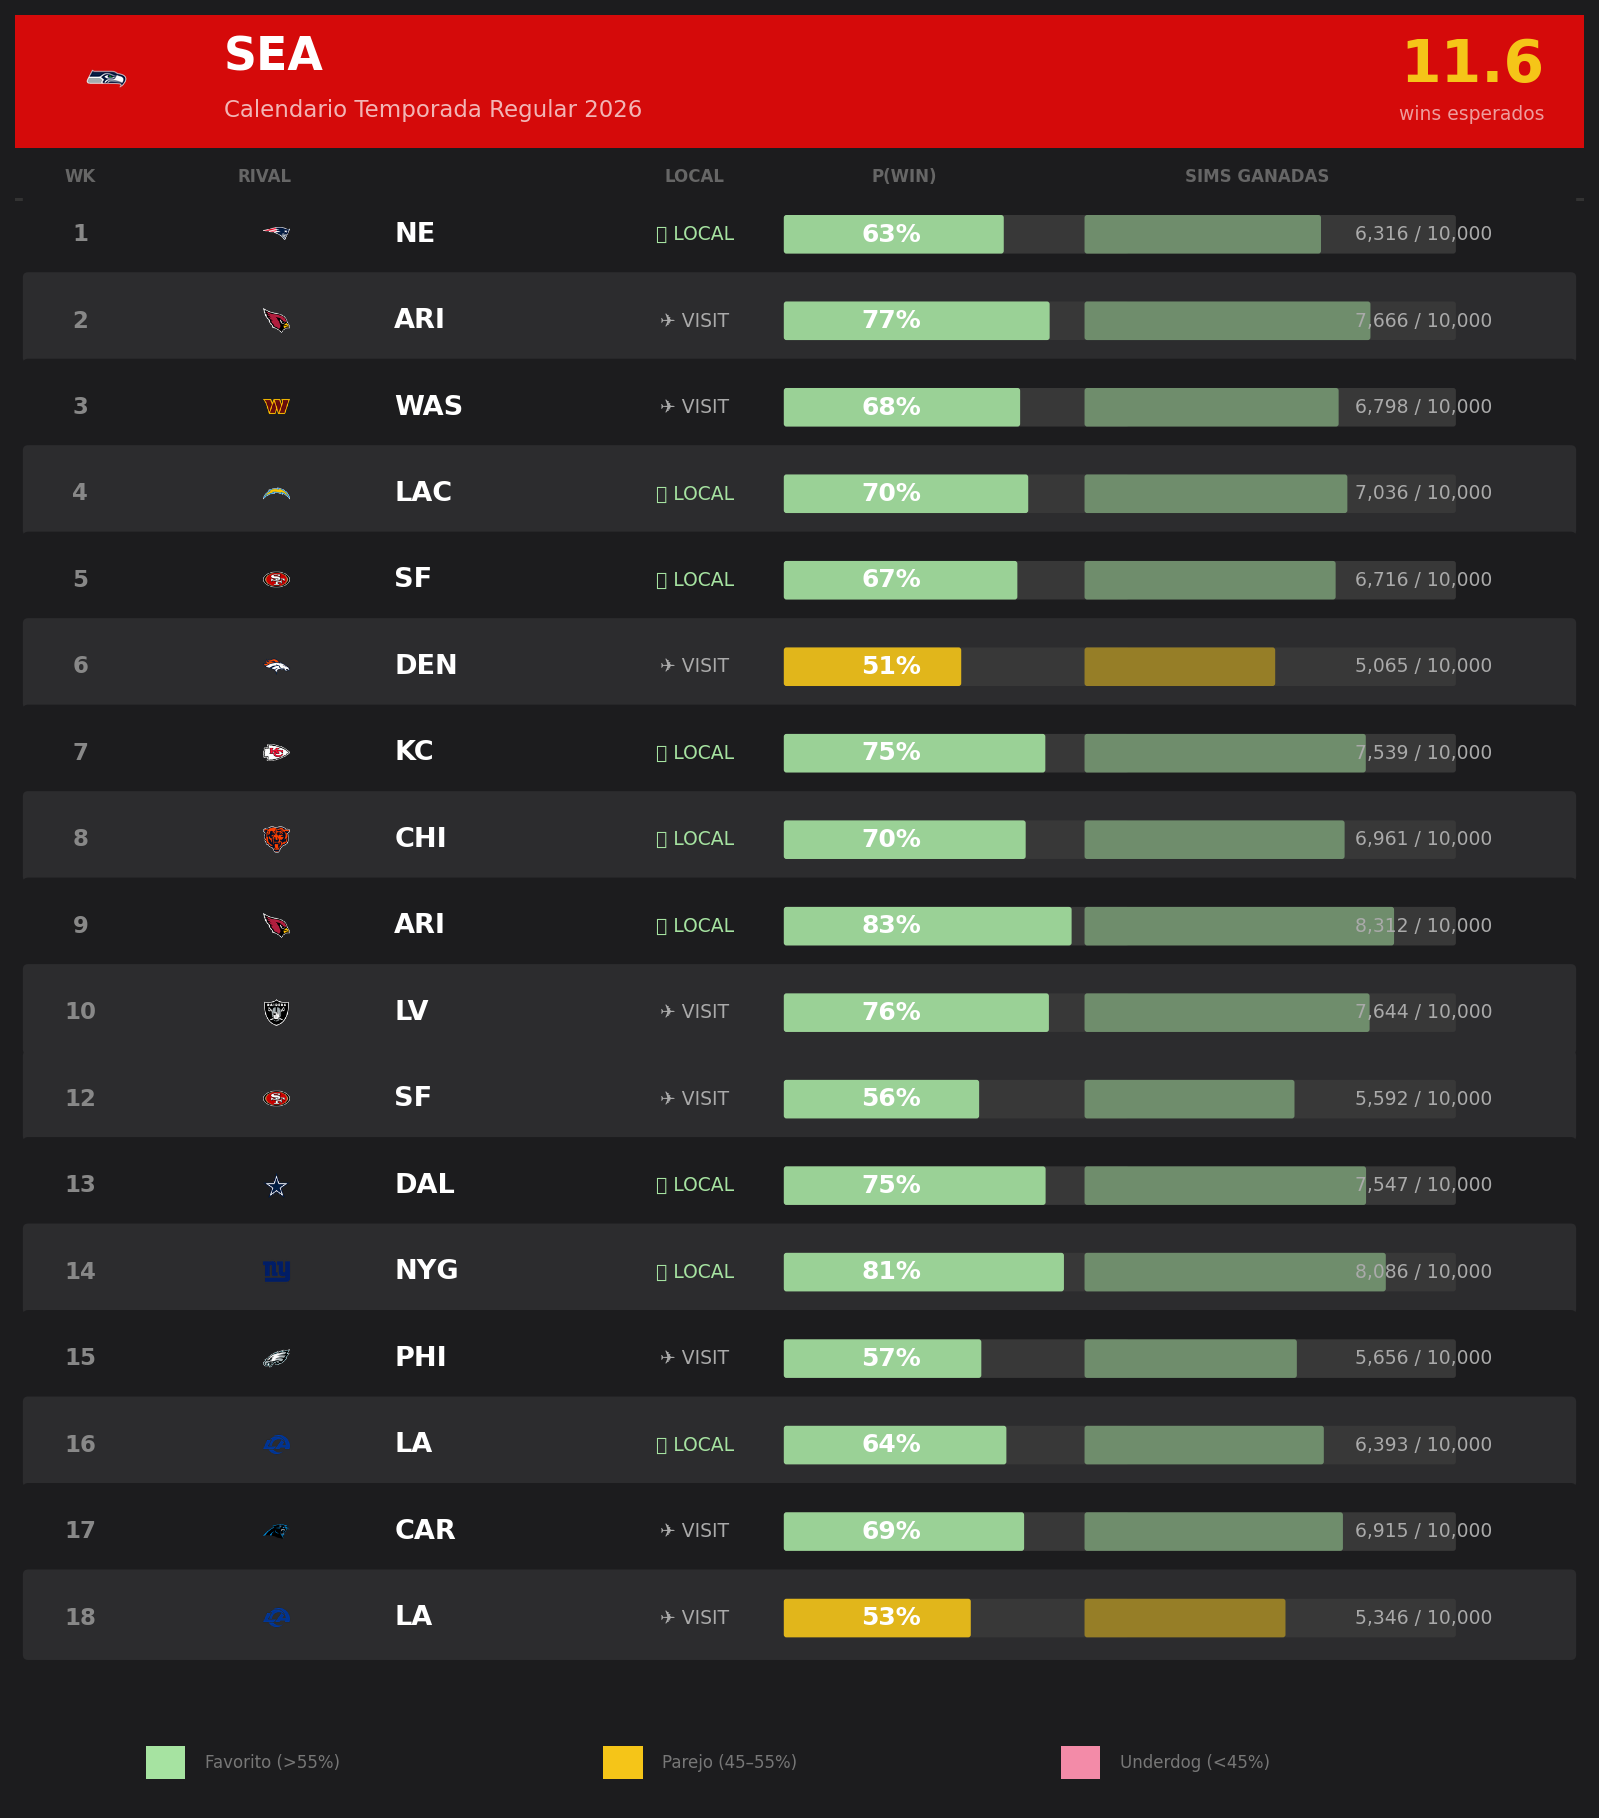

/Users/sebastianbp/Documents/GitHub/nfl_probability_engine/Notebooks/../src/visualization.py:613: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from current font.
  plt.tight_layout(pad=0)
/Users/sebastianbp/Documents/GitHub/nfl_probability_engine/Notebooks/../src/visualization.py:616: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight',


Guardado: ../results/schedule_KC_2026.png


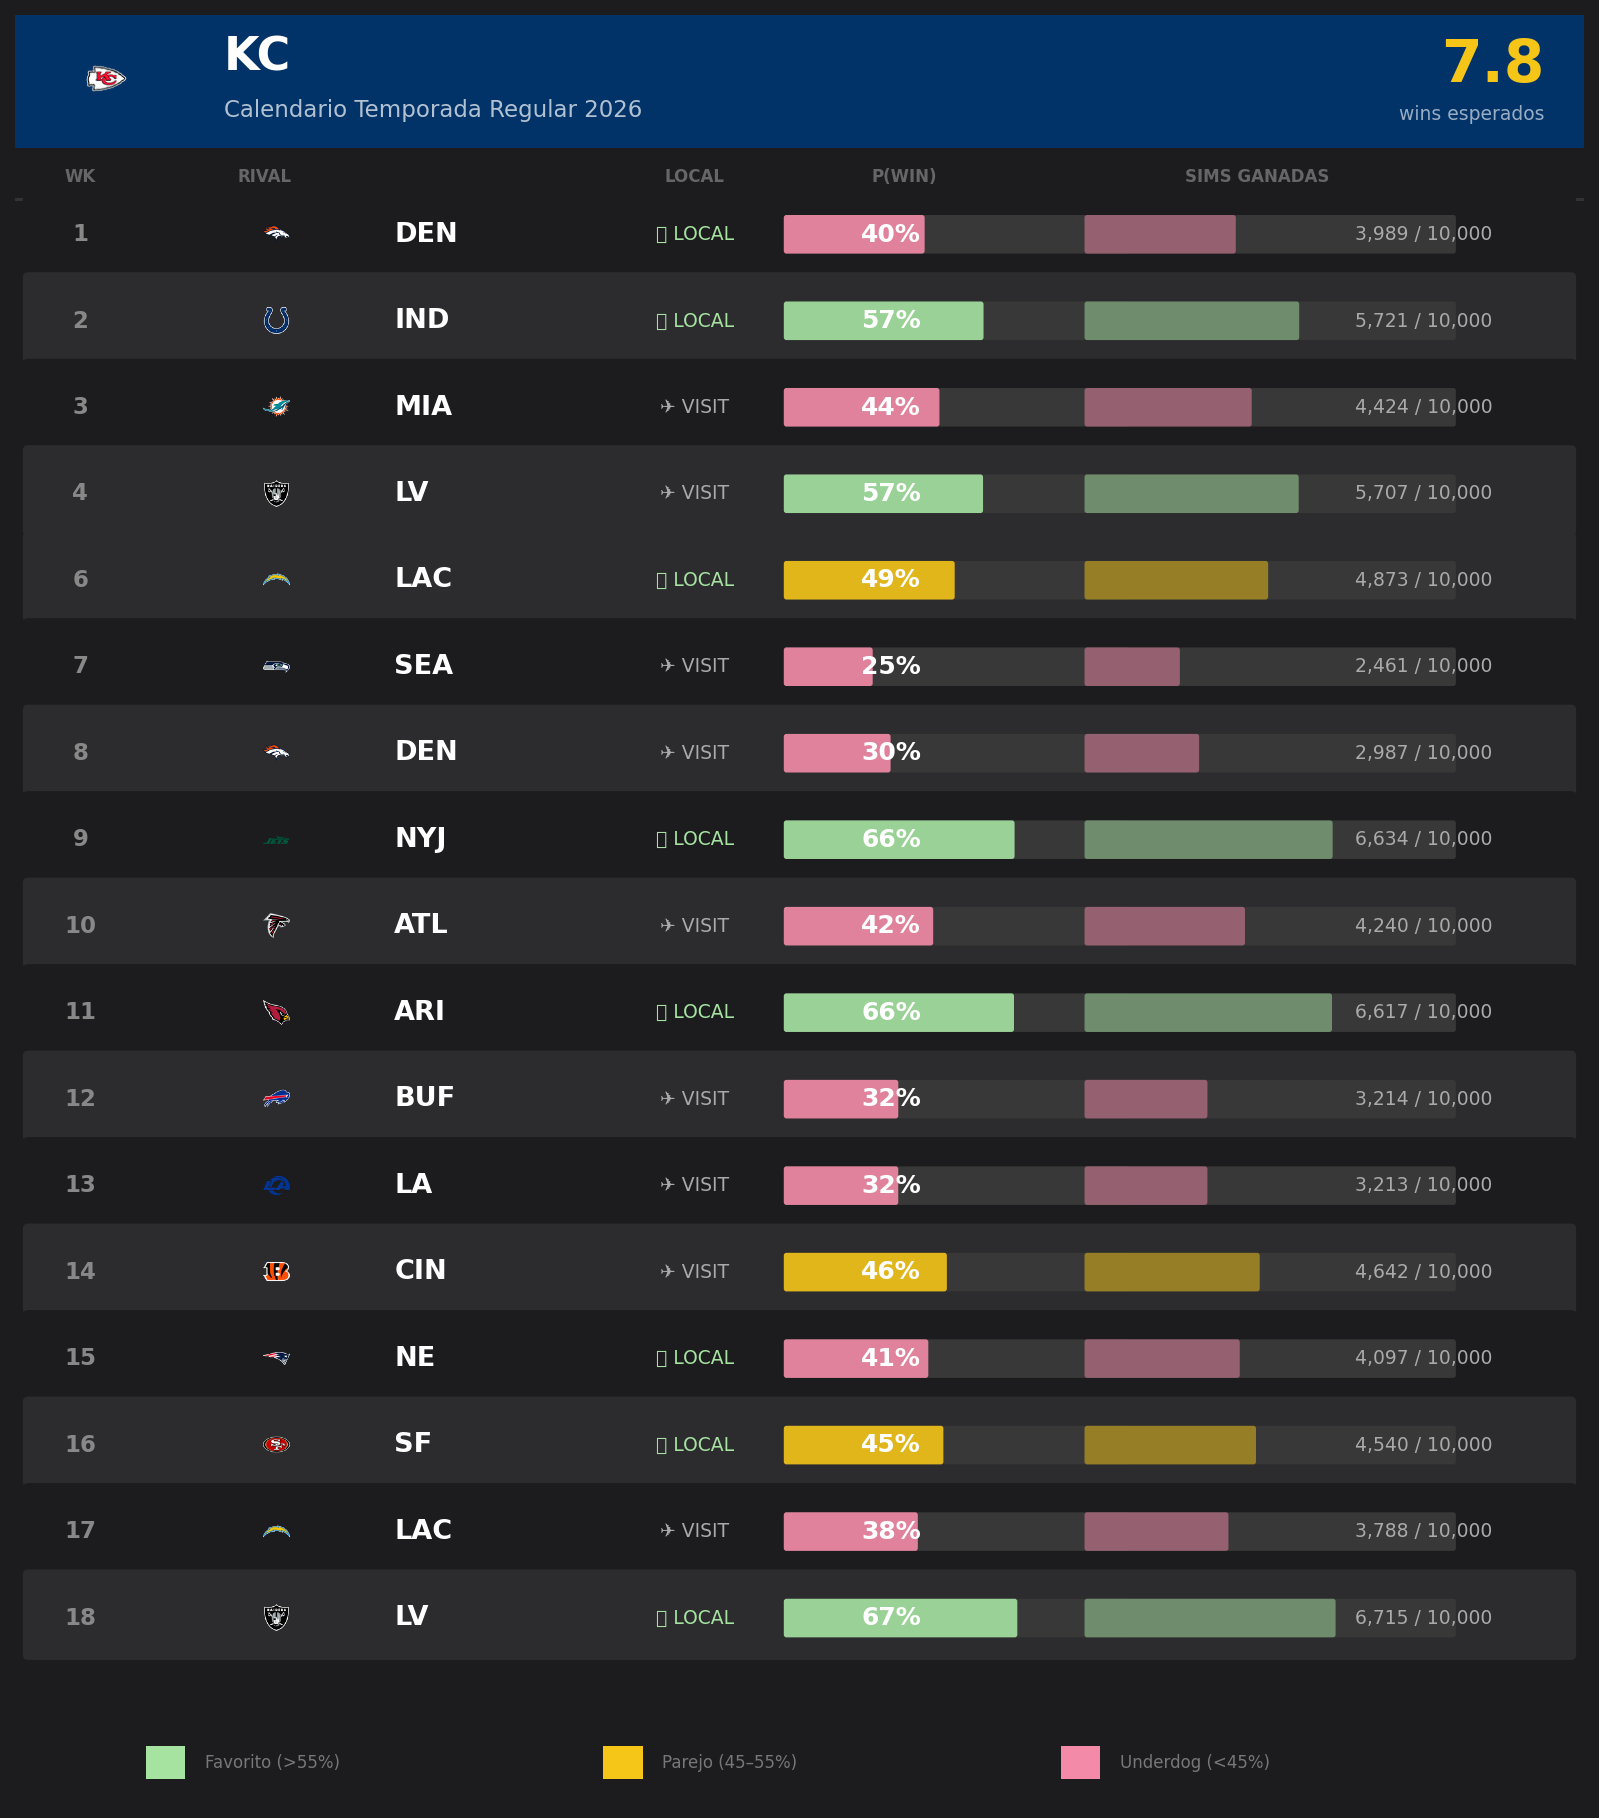

/Users/sebastianbp/Documents/GitHub/nfl_probability_engine/Notebooks/../src/visualization.py:613: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from current font.
  plt.tight_layout(pad=0)
/Users/sebastianbp/Documents/GitHub/nfl_probability_engine/Notebooks/../src/visualization.py:616: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight',


Guardado: ../results/schedule_NE_2026.png


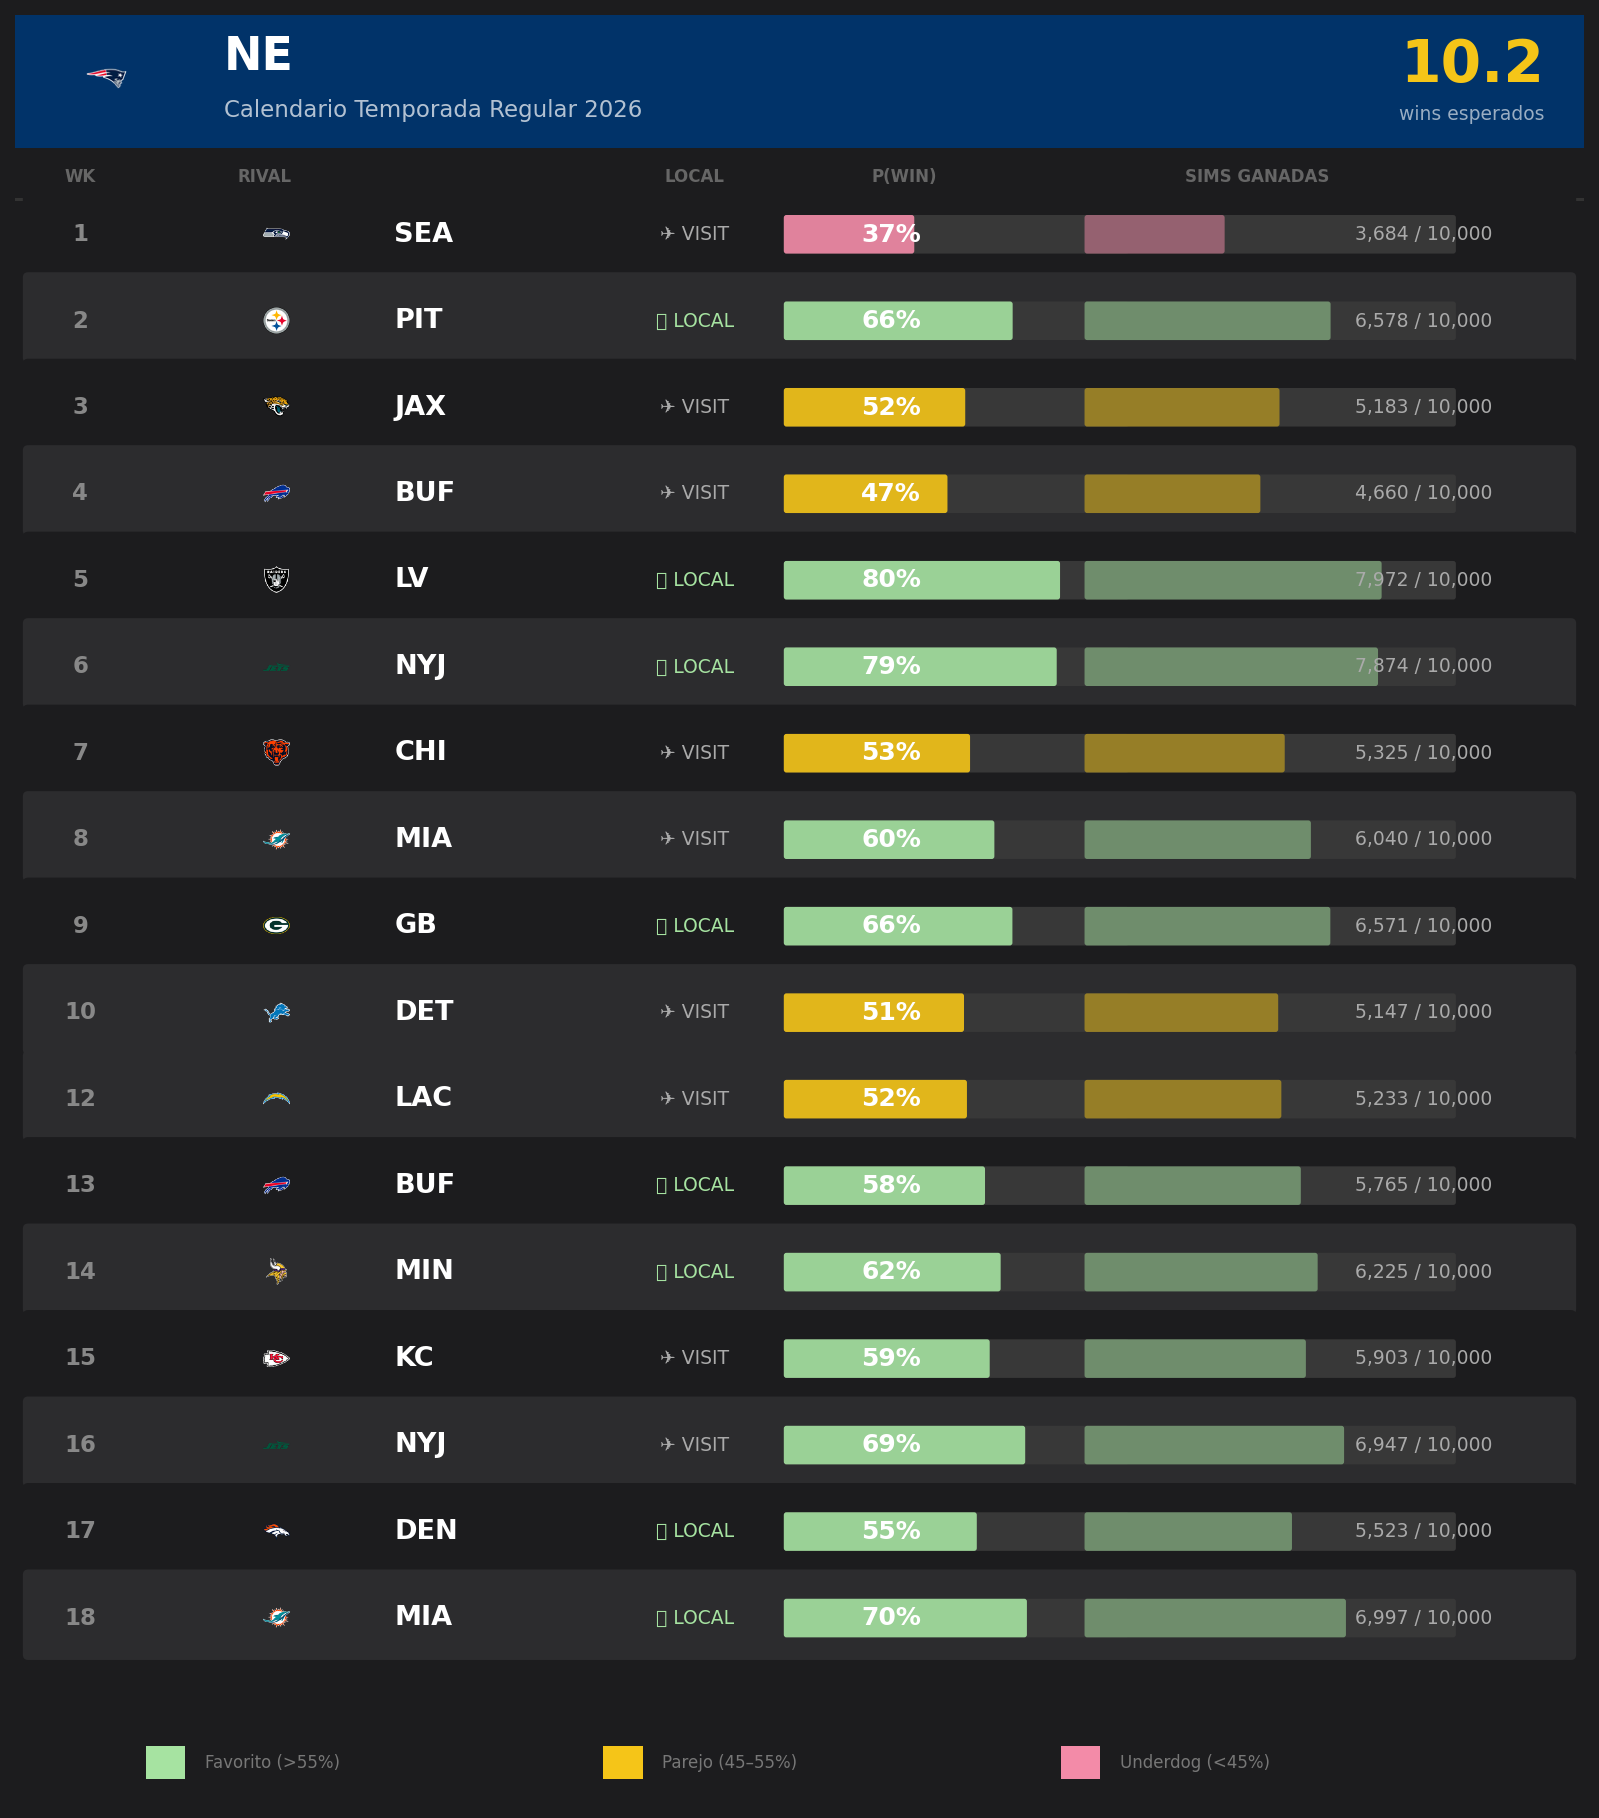

/Users/sebastianbp/Documents/GitHub/nfl_probability_engine/Notebooks/../src/visualization.py:613: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from current font.
  plt.tight_layout(pad=0)
/Users/sebastianbp/Documents/GitHub/nfl_probability_engine/Notebooks/../src/visualization.py:616: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight',


Guardado: ../results/schedule_LA_2026.png


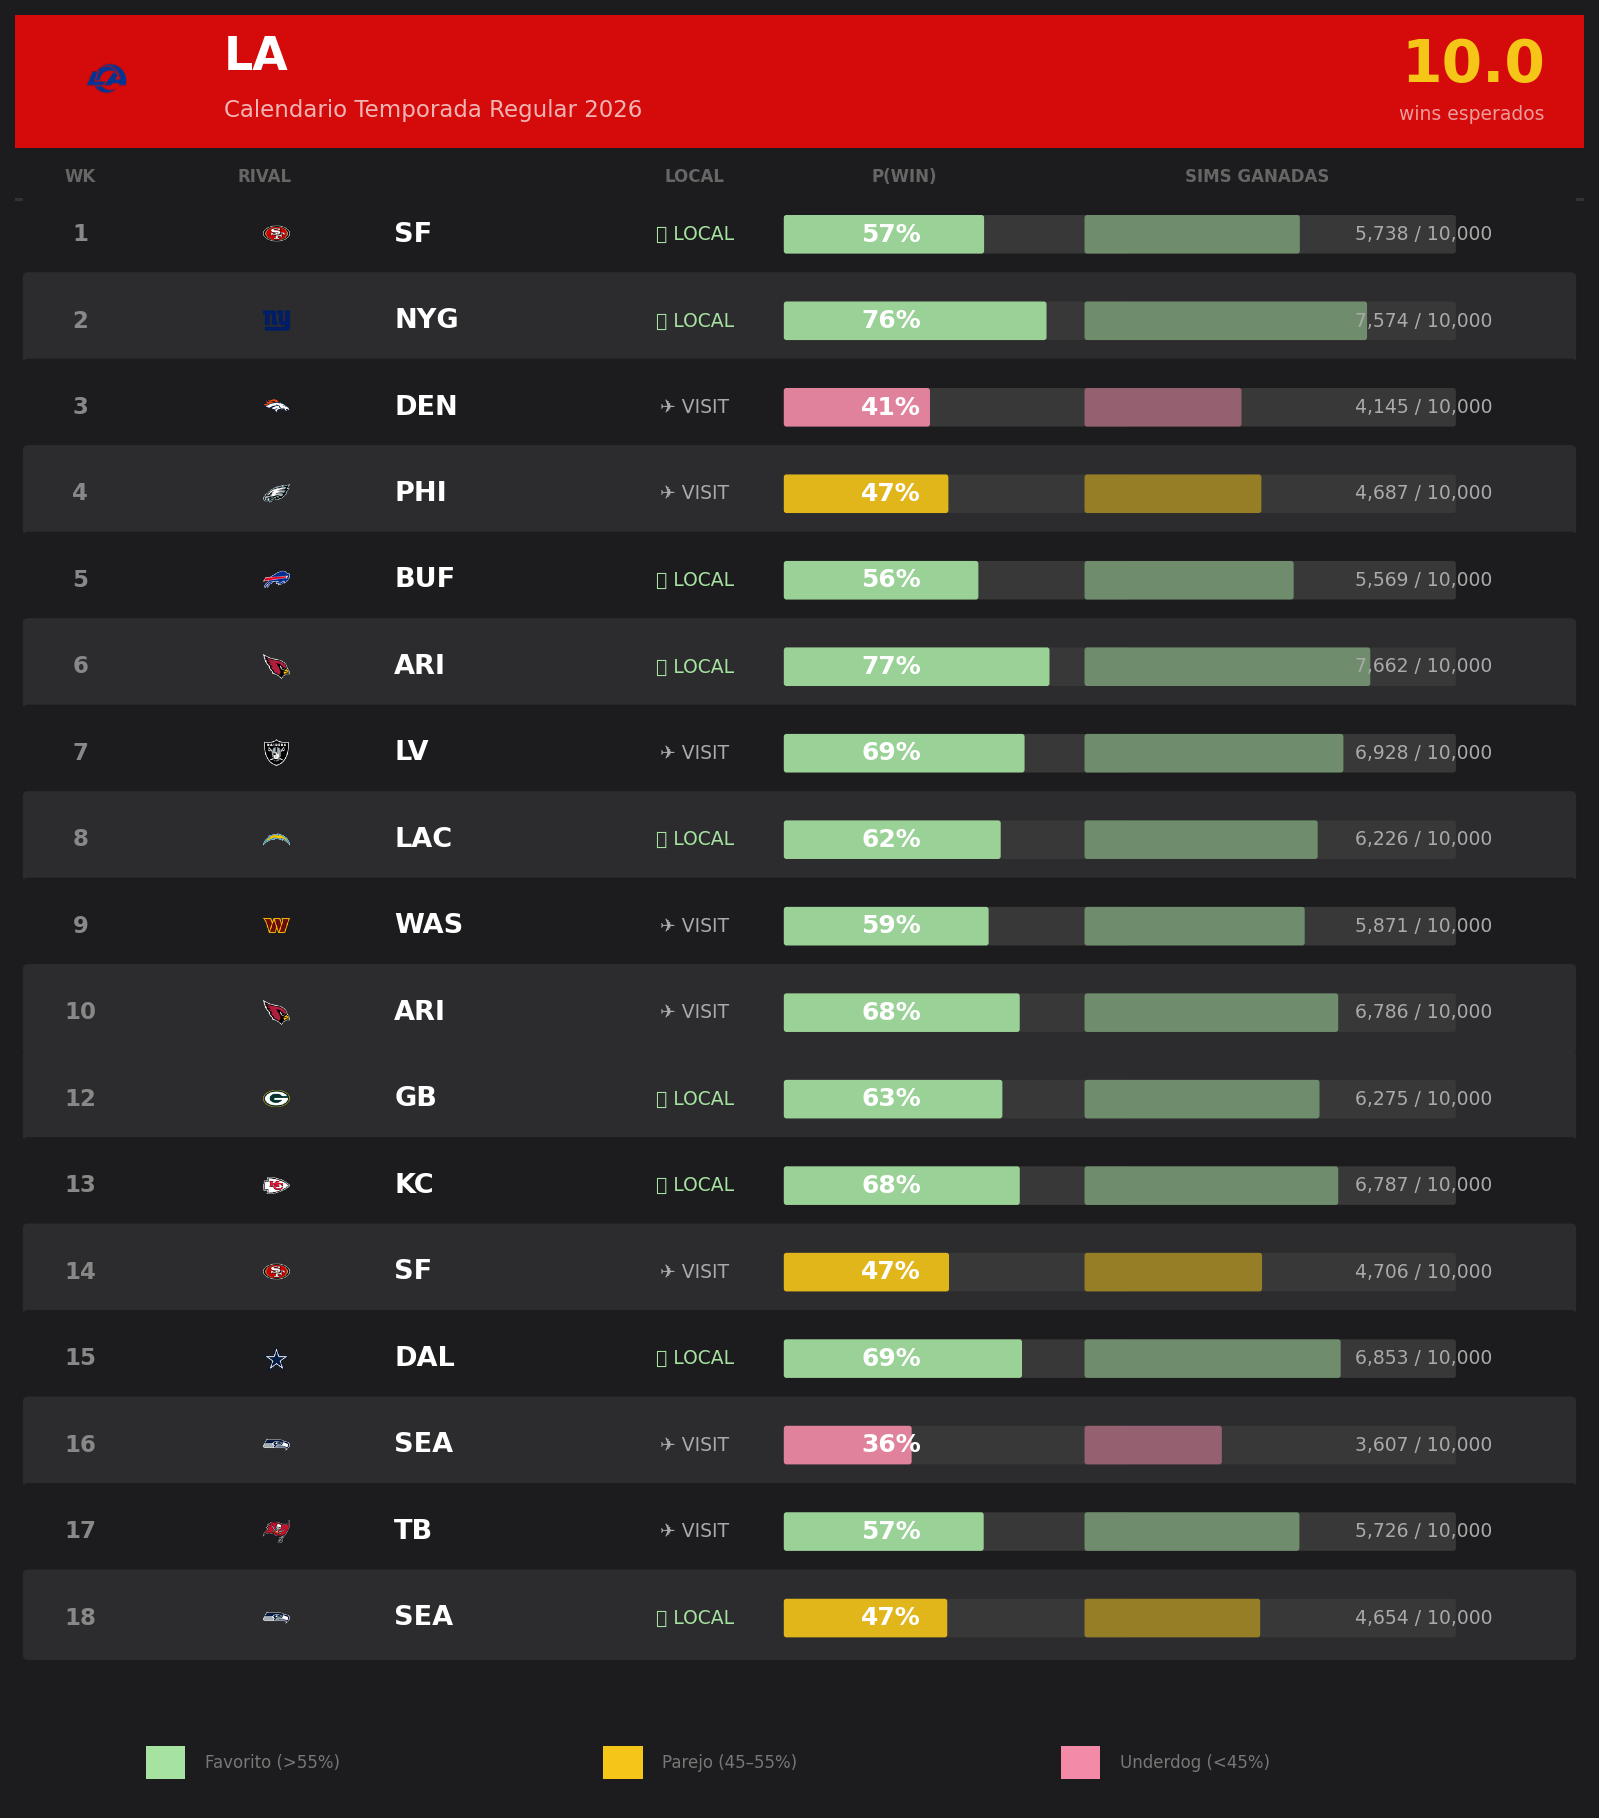

In [13]:
from src.visualization import (
    plot_regular_season_standings,
    plot_wildcard_bracket,
    plot_team_schedule
)

from IPython.display import Image, display

for team in ['SEA', 'KC', 'NE', 'LA']:
    plot_team_schedule(
        team=team,
        game_results_df=game_results_df,
        bg_color='#1c1c1e',
        save_path=f'../results/schedule_{team}_2026.png'
    )
    display(Image(f'../results/schedule_{team}_2026.png'))

/Users/sebastianbp/Documents/GitHub/nfl_probability_engine/Notebooks/../src/visualization.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.97])
/Users/sebastianbp/Documents/GitHub/nfl_probability_engine/Notebooks/../src/visualization.py:244: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout(rect=[0, 0.03, 1, 0.97])


Guardado en ../results/regular_season_standings_2026.png


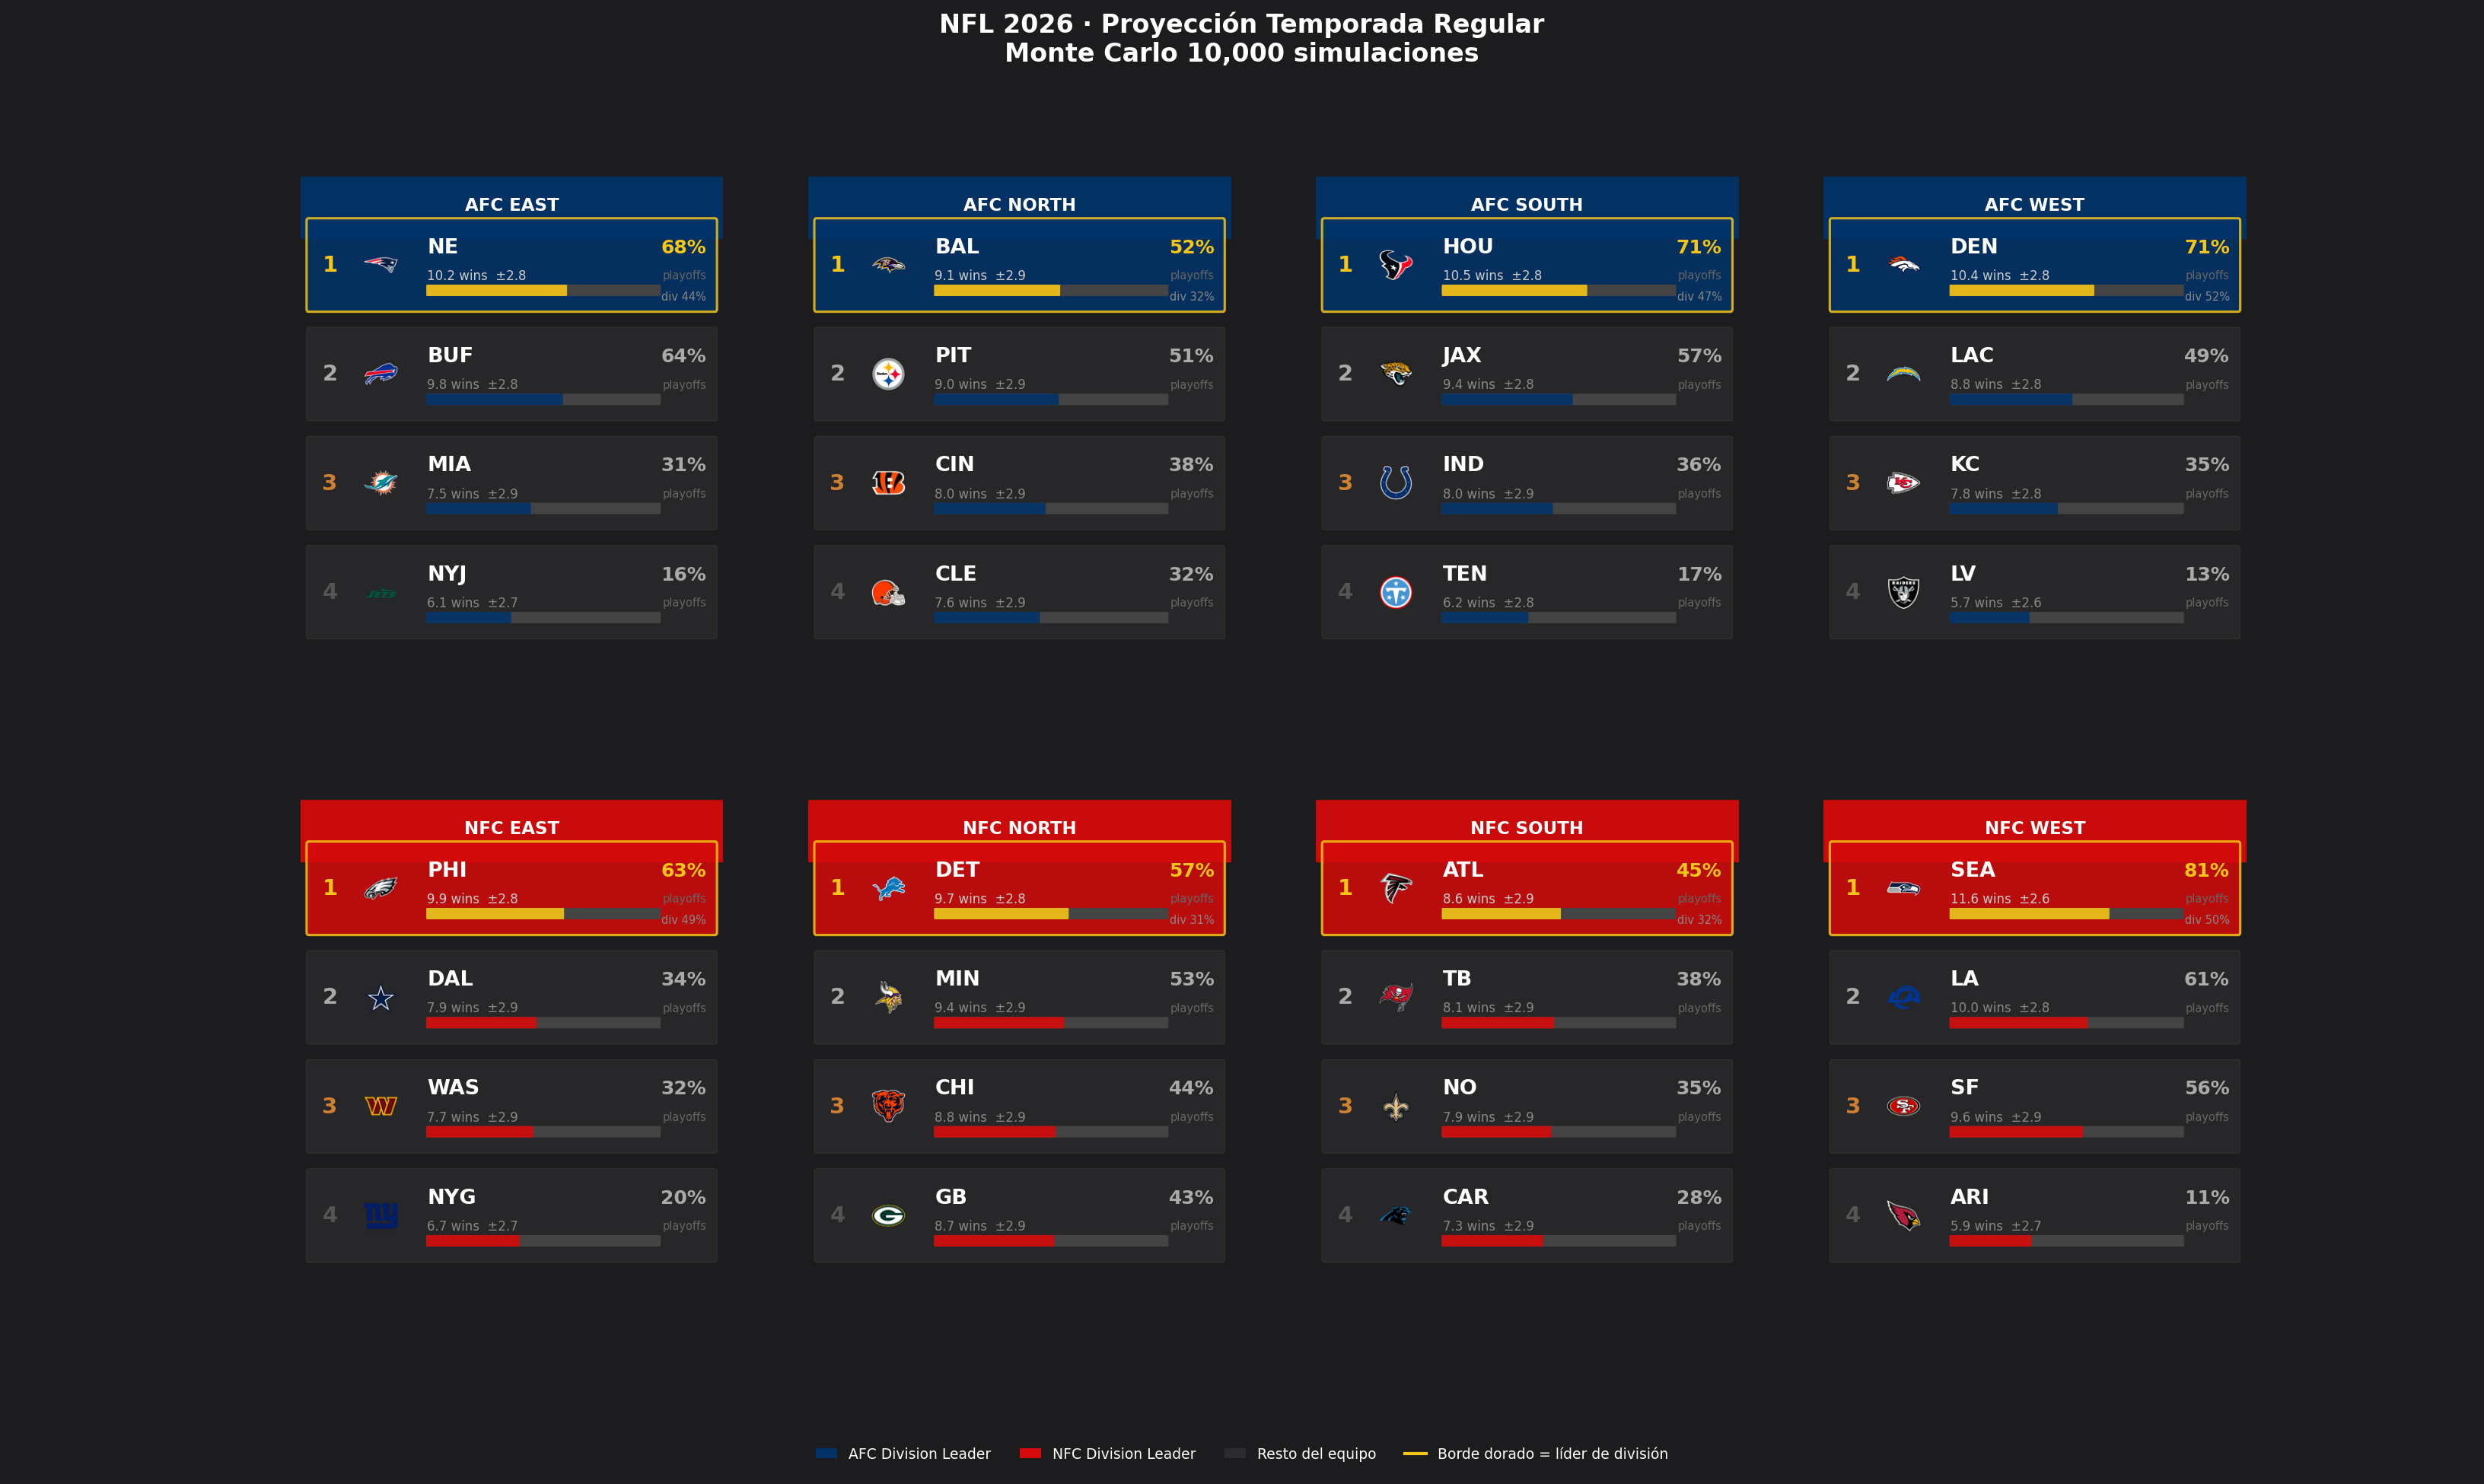

Guardado en ../results/wildcard_bracket_2026.png


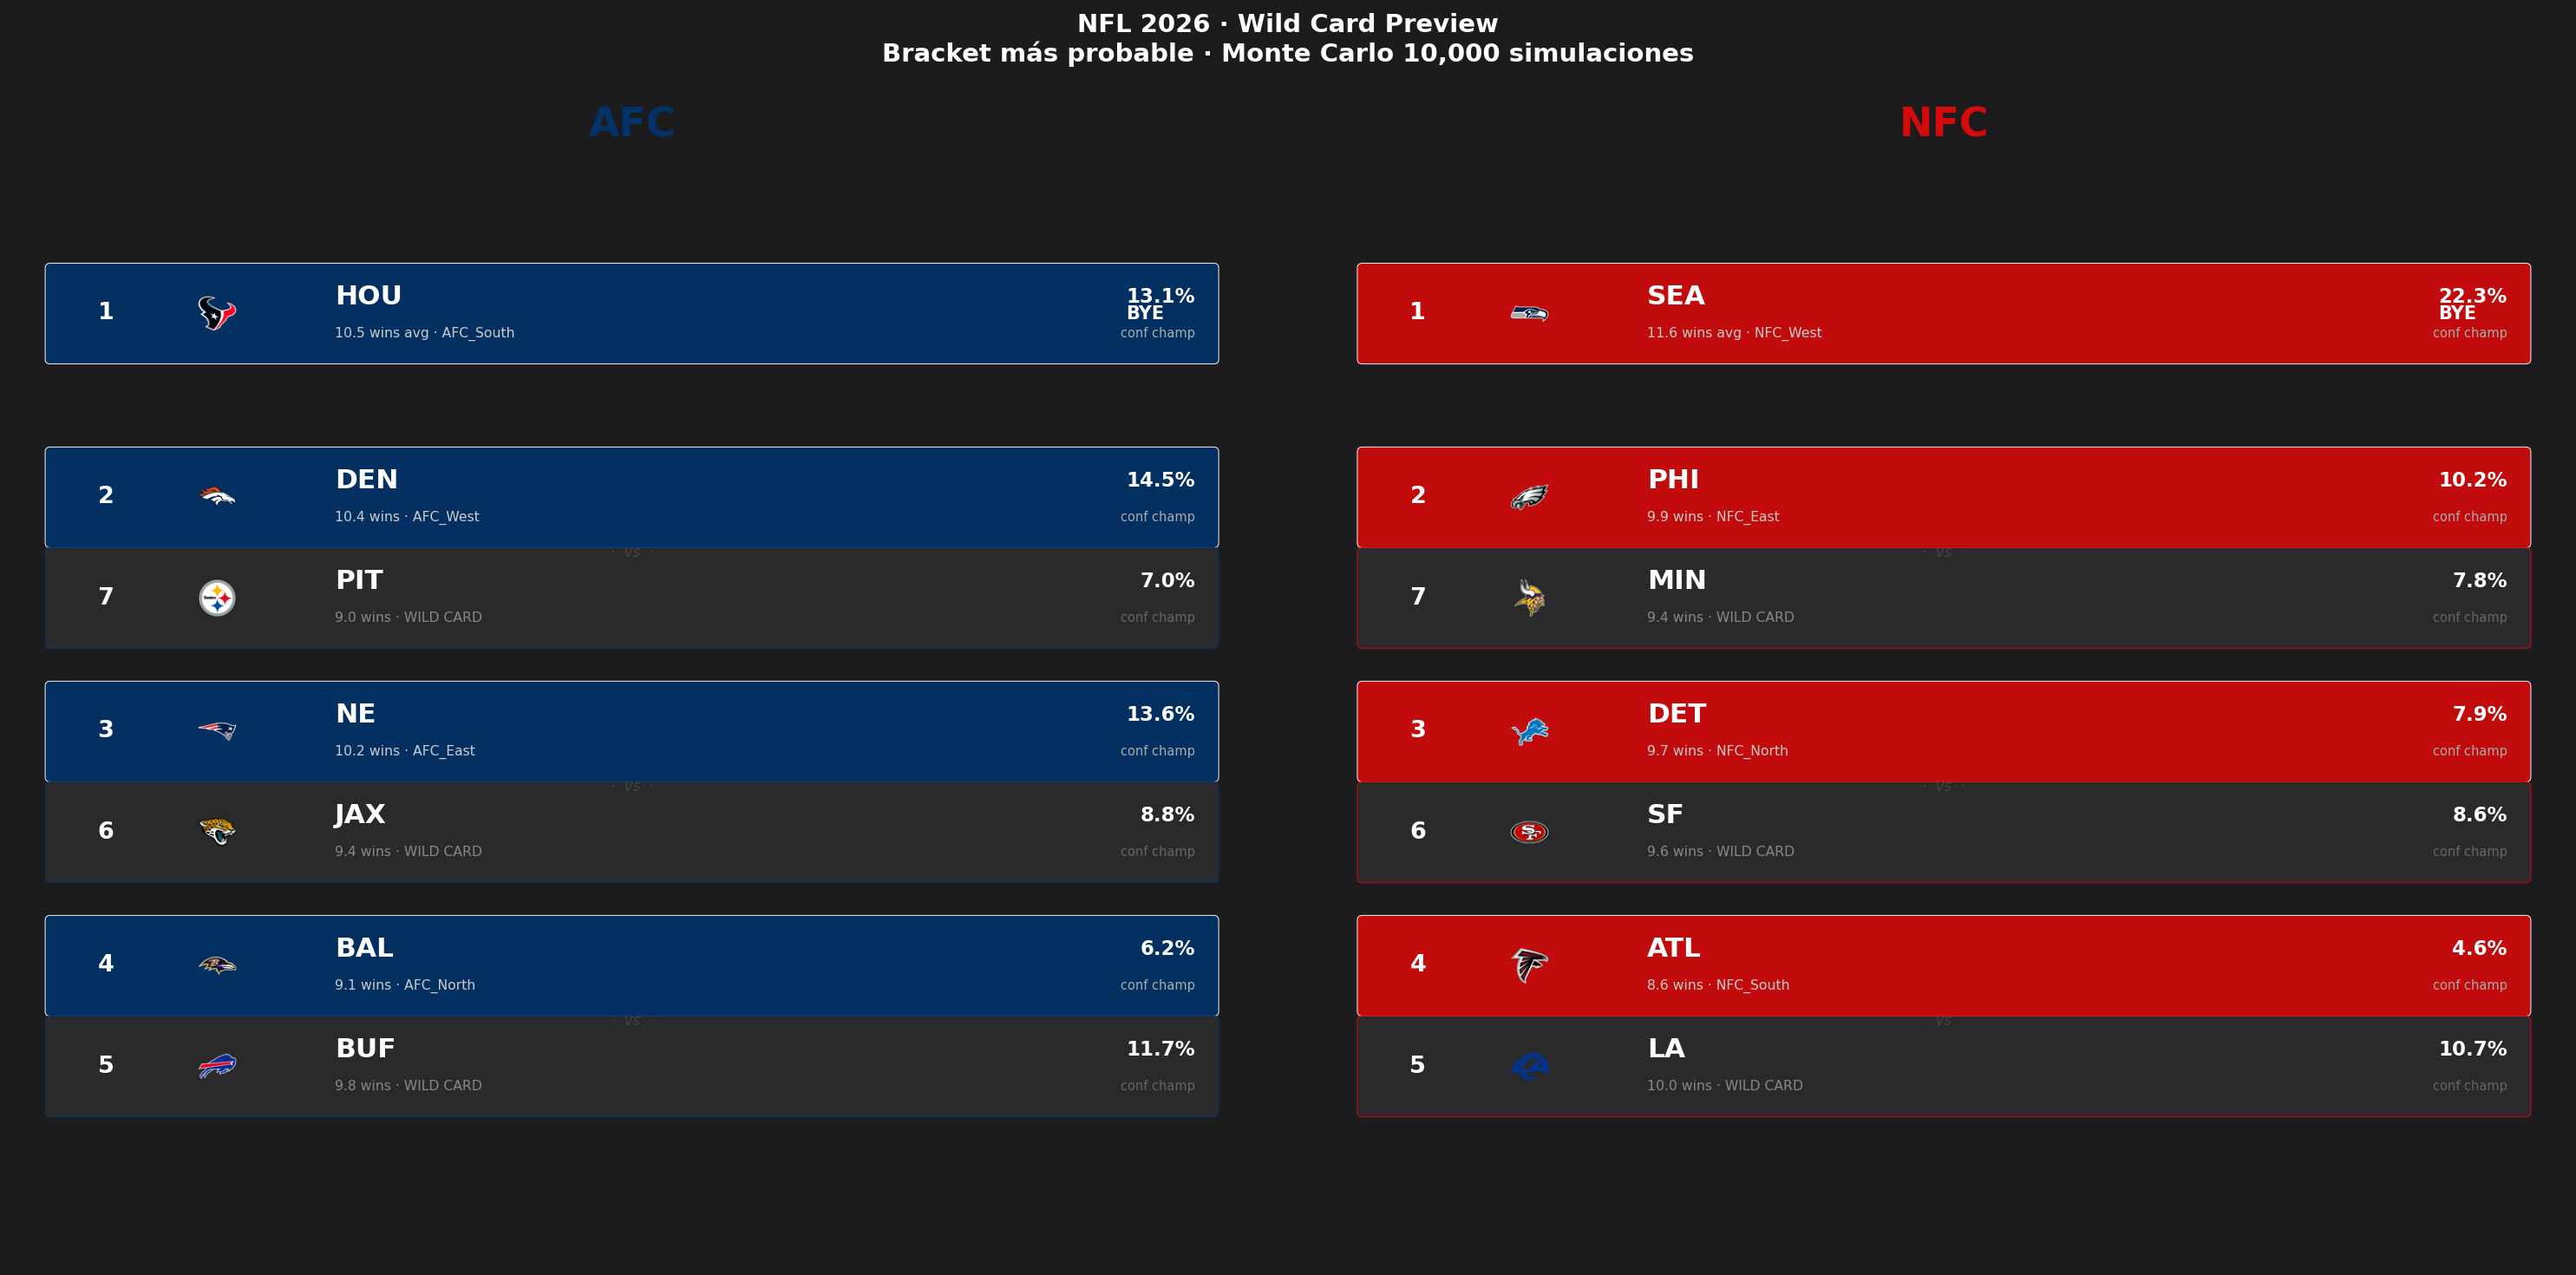

In [11]:
plot_regular_season_standings(
    results_df,
    bg_color='#1c1c1e',
    save_path='../results/regular_season_standings_2026.png'
)
display(Image('../results/regular_season_standings_2026.png'))

plot_wildcard_bracket(
    results_df,
    bg_color='#1c1c1e',
    save_path='../results/wildcard_bracket_2026.png'
)
display(Image('../results/wildcard_bracket_2026.png'))

In [12]:
game_results_df.query("home_team == 'LA' or away_team == 'LA'").sort_values('week')

,week,home_team,away_team,home_wins,away_wins,p_home_win,p_away_win
14,1,LA,SF,5738,4262,0.5738,0.4262
17,2,LA,NYG,7574,2426,0.7574,0.2426
33,3,DEN,LA,5855,4145,0.5855,0.4145
54,4,PHI,LA,5313,4687,0.5313,0.4687
64,5,LA,BUF,5569,4431,0.5569,0.4431
83,6,LA,ARI,7662,2338,0.7662,0.2338
94,7,LV,LA,3072,6928,0.3072,0.6928
111,8,LA,LAC,6226,3774,0.6226,0.3774
121,9,WAS,LA,4129,5871,0.4129,0.5871
140,10,ARI,LA,3214,6786,0.3214,0.6786
